In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
ds = pd.read_csv("https://raw.githubusercontent.com/datasets/breast-cancer/refs/heads/main/data/breast-cancer.csv")
ds.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


In [4]:
X = pd.get_dummies(ds.iloc[:, :-1],drop_first=True)
le = LabelEncoder()
y = le.fit_transform(ds.iloc[:, -1])

In [5]:
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
#Standard scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [7]:
#CONVERTING NUMPY ARRAYS TO PYTORCH TENSORS
import torch
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

In [8]:
X_train = X_train.float()
X_test  = X_test.float()
y_train = y_train.float()
y_test  = y_test.float()

In [9]:
from torch.utils.data import Dataset,DataLoader
class customdataset(Dataset) :
    def __init__(self,features,labels) :
        self.features = features
        self.labels = labels 

    def __len__(self) :
        return self.features.shape[0]

    def __getitem__(self,index) :
        return self.features[index] , self.labels[index] 
        

In [10]:
train_dataset = customdataset(X_train , y_train )
test_dataset = customdataset(X_test , y_test )

In [11]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [12]:
#DEFINING A MODEL
import torch.nn as nn

class mysimpleNN(nn.Module) :
    
  def __init__(self,num_features) :
      super().__init__() 
      self.network = nn.Sequential(
          nn.Linear(num_features,1) ,
          nn.Sigmoid() )
    #self.weights = torch.rand(X.shape[1],1,dtype = torch.float64,requires_grad=True) #here we writing (X.shape[1],1)--> for defining shape of rand function like 30 rows and 1 column

    #self.bias = torch.zeros(1,dtype = torch.float64,requires_grad=True)

  def forward(self,features) :
      out = self.network(features)
      return out 
      #z = torch.matmul(X,self.weights) + self.bias
      #y_pred = torch.sigmoid(z)
      #return y_pred



  #def loss_function(self, y_pred, y):
    # Clamp predictions to avoid log(0)
    #epsilon = 1e-7
    #y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    # Binary Cross Entropy Loss
    #loss = -(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred)).mean()

    #return loss


In [13]:
#LEARNING PARAMETERS
learning_rate = 0.1
epochs = 25

In [14]:
loss_function = nn.BCELoss()

#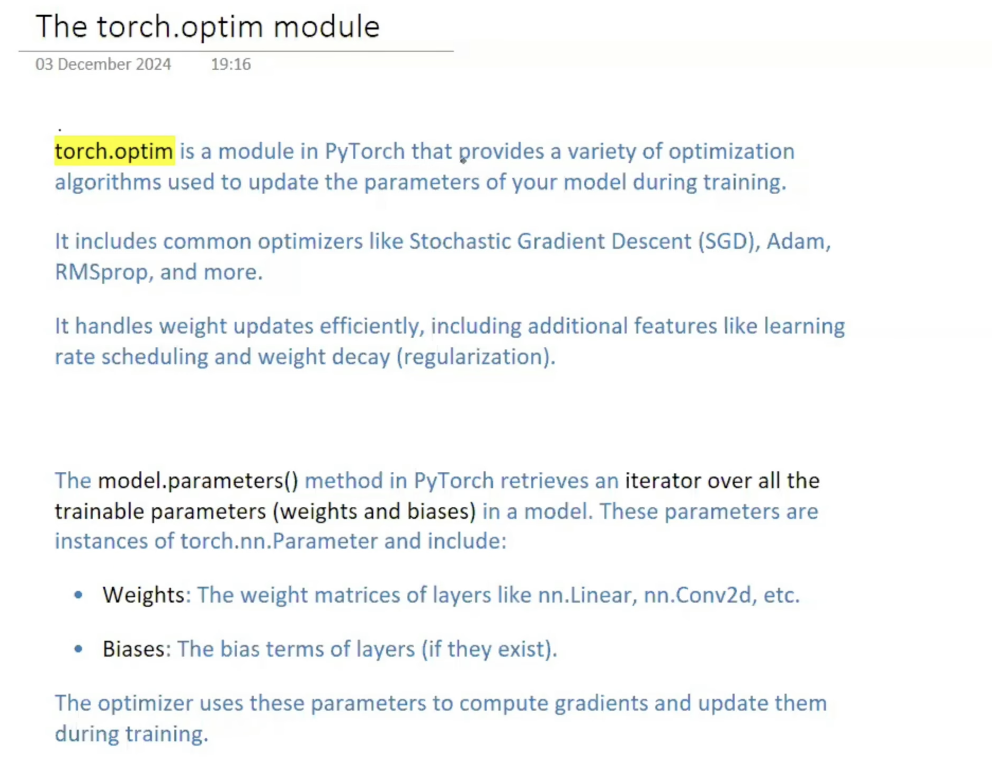 # JUST EXPLAINING THE OPTIMIZER MODULE

In [15]:
# TRAINING PIPELINE

#CREATING MODEL
model = mysimpleNN(X_train.shape[1])

#define optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

#DEFINE LOOP
for epoch in range(epochs) :
    for batch_features  , batch_labels in train_loader  :
        
        #forward
        y_pred = model(batch_features)
        
        #loss
        loss = loss_function(y_pred,batch_labels.view(-1,1))
    
#{view(-1, 1)
#It reshapes a tensor (changes its dimensions)}
# -1 -->	PyTorch automatically decides this size
# 1 -->	Make it 1 column

    
       # Reset gradients
        optimizer.zero_grad()

    #model.network[0].weight.grad.zero_()
    #model.network[0].bias.grad.zero_()


        #backward
        loss.backward()

      #PARAMETERS UPDATING
        optimizer.step()
  #with torch.no_grad() :
    #model.network[0].weight -= learning_rate * model.network[0].weight.grad
    #model.network[0].bias -= learning_rate * model.network[0].bias.grad


    #model.network[0].weight.grad.zero_()
    #model.network[0].bias.grad.zero_()

        print(f'Epoch:{epoch+1} , Loss:{loss}')



Epoch:1 , Loss:0.6549667119979858
Epoch:1 , Loss:0.6164209246635437
Epoch:1 , Loss:0.7056341171264648
Epoch:1 , Loss:0.7040809988975525
Epoch:1 , Loss:0.8637394905090332
Epoch:1 , Loss:0.8632463812828064
Epoch:1 , Loss:0.4657745361328125
Epoch:2 , Loss:0.5539470911026001
Epoch:2 , Loss:0.488211452960968
Epoch:2 , Loss:0.6671370267868042
Epoch:2 , Loss:0.6916207671165466
Epoch:2 , Loss:0.5009270906448364
Epoch:2 , Loss:0.466009259223938
Epoch:2 , Loss:0.45476868748664856
Epoch:3 , Loss:0.4802120327949524
Epoch:3 , Loss:0.468658983707428
Epoch:3 , Loss:0.5578668117523193
Epoch:3 , Loss:0.42512038350105286
Epoch:3 , Loss:0.6066489219665527
Epoch:3 , Loss:0.5206679701805115
Epoch:3 , Loss:0.731753408908844
Epoch:4 , Loss:0.44096115231513977
Epoch:4 , Loss:0.611870288848877
Epoch:4 , Loss:0.3703310191631317
Epoch:4 , Loss:0.4607408046722412
Epoch:4 , Loss:0.6467146277427673
Epoch:4 , Loss:0.5485444068908691
Epoch:4 , Loss:0.6534299254417419
Epoch:5 , Loss:0.44180458784103394
Epoch:5 , Loss:

In [16]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        y_pred = model(batch_features)
        y_pred = (y_pred > 0.8).float()

        correct += (y_pred.view(-1) == batch_labels).sum().item()
        total += batch_labels.size(0)

overall_accuracy = correct / total
print(f'Accuracy: {overall_accuracy:.4f}')

Accuracy: 0.7091
